In [1]:
# This code grabs all feature_counts tables from a path and combines them into a feature table
import pandas as pd
import glob
import os

# Path to your featureCounts output files
input_dir = "/mnt/Disk07/slicandro/ACAJOACO/Secuenciacion_Paneles/DAPPSeq_pipeline/results/feature_counts/"
files = glob.glob(os.path.join(input_dir, "*AMR*"))

# Initialize list to hold dataframes
dfs = []

for f in files:
    # Read file, skipping comment lines (#)
    df = pd.read_csv(f, sep="\t", comment="#")
    
    # Extract Geneid and the last column (counts)
    sample_name = os.path.splitext(os.path.basename(f))[0]
    df = df[["Geneid", df.columns[-1]]]
    df.columns = ["Geneid", sample_name]
    
    dfs.append(df)

# Merge all dataframes on Geneid
merged = dfs[0]
for df in dfs[1:]:
    merged = pd.merge(merged, df, on="Geneid", how="outer")

# Fill missing values with 0
merged = merged.fillna(0).astype({col: int for col in merged.columns if col != "Geneid"})

# Save final counts table
merged.to_csv("ResFinder_AMR_merged_counts.tsv", sep="\t", index=False)


In [2]:
# Now we load a metadata file and map the colnames of the counts table to sample IDs in the metadata.
metadata = pd.read_csv("/mnt/Disk07/slicandro/ACAJOACO/Secuenciacion_Paneles/DAPPSeq_pipeline/metadata/metadata_sec2025_AMR.csv")

# I need to strip the names of the columns of the count table and retrieve the barcode data contained just after "IonCode_" and before the next underscore. Also it must remove the 0 on the left.
def extract_barcode(colname):
    if "IonCode_" in colname:
        start = colname.index("IonCode_") + len("IonCode_")
        end = colname.find("_", start)
        if end == -1:
            end = len(colname)
        return colname[start:end].lstrip("0")
    return None
barcode_map = {col: extract_barcode(col) for col in merged.columns if col != "Geneid"}
# Create a mapping from barcode to sample ID
# Normalizo la columna de metadata: todo string, sin espacios y sin ceros a la izquierda 
metadata = metadata.copy() 
metadata['BARCODE_norm'] = metadata['BARCODE'].astype(str).str.strip().str.lstrip("0")

barcode_to_sample = dict(zip(metadata['BARCODE_norm'], metadata['POOL'].astype(str)))

new_column_names = {} 
unmatched = {}

for col, bc in barcode_map.items():
    if bc is None:
        continue
    sample = barcode_to_sample.get(bc)
    if sample is not None:
        new_column_names[col] = sample
    else:
        unmatched[col] = bc
print(f"Columnas detectadas con IonCode_: {len(barcode_map)}") 
print(f"Columnas mapeadas con éxito: {len(new_column_names)}") 
print(f"Columnas sin match en metadata: {len(unmatched)}")

if unmatched: 
    print("Ejemplos de columnas sin match (colname -> barcode extraído):") 
    for col, bc in list(unmatched.items())[:20]: 
        print(f" {col} -> '{bc}'")

merged = merged.rename(columns=new_column_names)

# Guardar resultado 
merged.to_csv("AMR_ResFinder_merged_counts_renamed.tsv", sep="\t", index=False) 
print("Archivo guardado como AMR_ResFinder_merged_counts_renamed.tsv")

Columnas detectadas con IonCode_: 36
Columnas mapeadas con éxito: 36
Columnas sin match en metadata: 0
Archivo guardado como AMR_ResFinder_merged_counts_renamed.tsv


In [3]:
merged

,Geneid,BOX_15_MM,BOX_37_MM,BOX_37_JUL,BOX_40_MM,BOX_38_DIC,BOX_38_JUL,BOX_42_JUL,BOX_15_DIC,BOX_39_DIC,...,BOX_18_DIC,BOX_17_JUL,BOX_17_MM,BOX_39_JUL,BOX_16_DIC,BOX_18_MM,BOX_38_MM,BOX_41_DIC,BOX_14_MM,BOX_39_MM
0,ARR-2_1_HQ141279,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ARR-3_1_JF806499,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ARR-3_4_FM207631,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ARR-4_1_EF660562,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ARR-5_1_EF660563,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3208,vga(C)_1_FN806792,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3209,vga(D)_1_GQ205627,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3210,vga(E)_1_FR772051,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3211,vgb(A)_1_M20129,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


/mnt/Disk07/slicandro/miniconda/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/mnt/Disk07/slicandro/miniconda/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


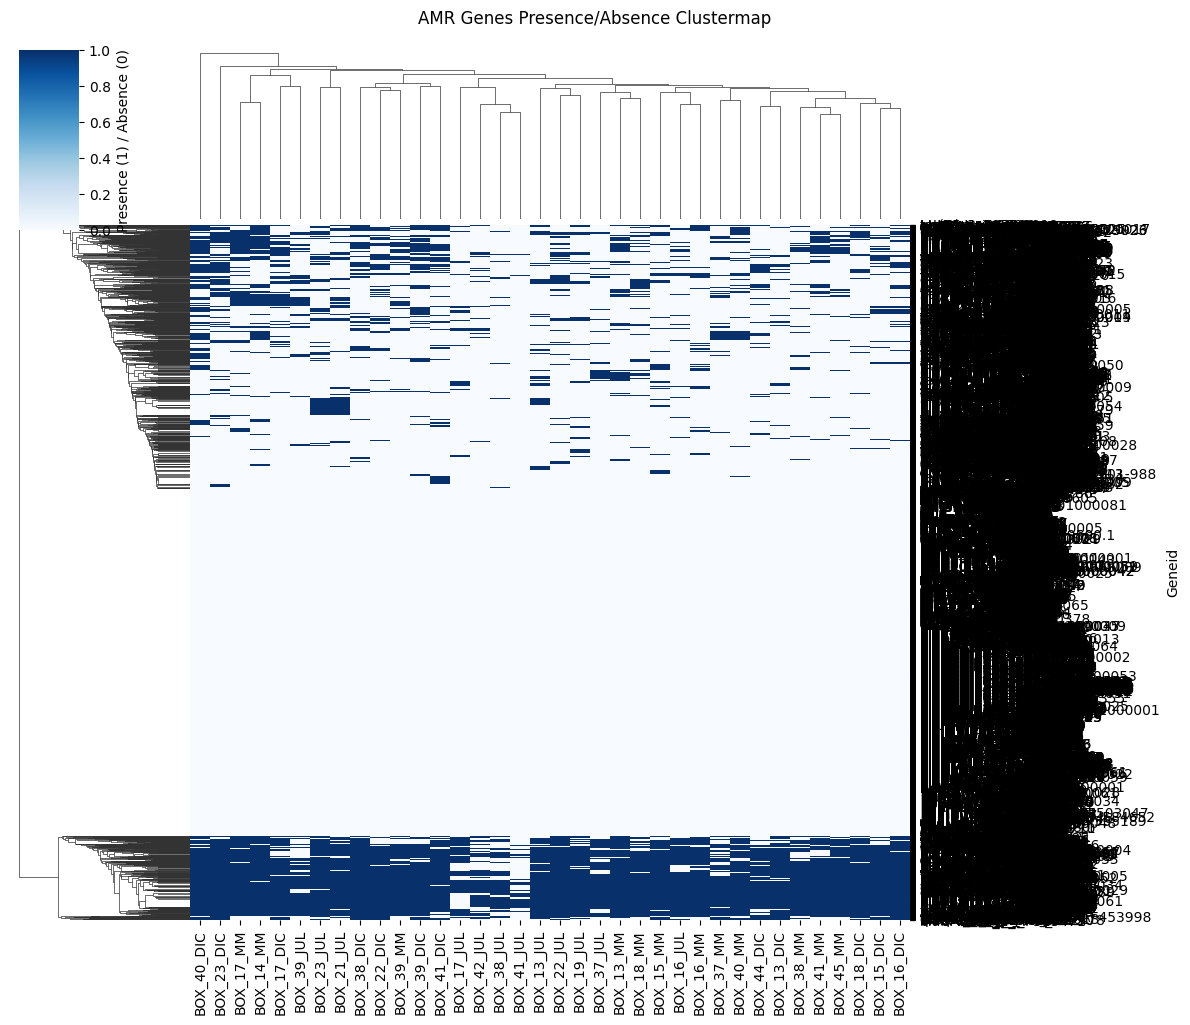

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

# Convert counts to presence/absence (1 = present, 0 = absent)
presence_absence = merged.set_index("Geneid").astype(bool).astype(int)

# Create clustermap
g = sns.clustermap(
    presence_absence,
    cmap="Blues",
    cbar_kws={'label': 'Presence (1) / Absence (0)'},
    figsize=(12, 10),
    yticklabels=True,
)

# Add a title properly
g.fig.suptitle("AMR Genes Presence/Absence Clustermap", y=1.02)

# Save the figure
#g.savefig("AMR_ResFinder_presence_absence_clustermap.png", dpi=300)

plt.show()

In [5]:
merged

,Geneid,BOX_15_MM,BOX_37_MM,BOX_37_JUL,BOX_40_MM,BOX_38_DIC,BOX_38_JUL,BOX_42_JUL,BOX_15_DIC,BOX_39_DIC,...,BOX_18_DIC,BOX_17_JUL,BOX_17_MM,BOX_39_JUL,BOX_16_DIC,BOX_18_MM,BOX_38_MM,BOX_41_DIC,BOX_14_MM,BOX_39_MM
0,ARR-2_1_HQ141279,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ARR-3_1_JF806499,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ARR-3_4_FM207631,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ARR-4_1_EF660562,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ARR-5_1_EF660563,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3208,vga(C)_1_FN806792,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3209,vga(D)_1_GQ205627,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3210,vga(E)_1_FR772051,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3211,vgb(A)_1_M20129,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# Que tipos de resistencia antibiotica son mas abundantes?

# Cargamos la tabla de phenotypes de ResFinder y mapeamos las resistencias a la primera columna para recuperar la informacion contenida en la columna Class
import pandas as pd

# phenotypes.txt viene así: Gene | Class | Phenotype
pheno_df = pd.read_csv("/mnt/Disk07/slicandro/ACAJOACO/Secuenciacion_Paneles/resfinder/resfinder_db/phenotypes.txt",
                       sep="\t")

# Asegurar que los nombres de genes coinciden entre tablas
pheno_df["Geneid"] = pheno_df["Gene_accession no."].str.strip()
print(pheno_df.head())
# Asumo que 'merged' tiene una columna con los genes encontrados, por ejemplo merged["Gene"]
# Si tu columna tiene otro nombre, cambialo acá:
if "Geneid" not in merged.columns:
    print("⚠️ Asegurate de que el DataFrame 'merged' tenga una columna llamada 'Gene' con los nombres de los genes detectados.")

# Hacemos el merge para añadir la clase antibiótica a cada gen encontrado
merged_with_class = merged.merge(pheno_df[["Geneid", "Class"]], on="Geneid", how="left")

# Contamos por clase
class_counts = merged_with_class["Class"].value_counts().reset_index()
class_counts.columns = ["Antibiotic_Class", "Count"]

# Mostramos las clases más abundantes
class_counts

        Gene_accession no.           Class               Phenotype  \
0     ant(2'')-Ia_1_X04555  Aminoglycoside  Gentamicin, Tobramycin   
1  ant(2'')-Ia_10_HM367617  Aminoglycoside  Gentamicin, Tobramycin   
2  ant(2'')-Ia_11_HM367620  Aminoglycoside  Gentamicin, Tobramycin   
3  ant(2'')-Ia_12_HQ880250  Aminoglycoside  Gentamicin, Tobramycin   
4  ant(2'')-Ia_13_DQ176450  Aminoglycoside  Gentamicin, Tobramycin   

          PMID Mechanism of resistance                  Notes Required_gene  \
0      3024112  Enzymatic modification  Alternative name aadB           NaN   
1     21873033  Enzymatic modification                    NaN           NaN   
2     21873033  Enzymatic modification                    NaN           NaN   
3  unpublished  Enzymatic modification                    NaN           NaN   
4     16304199  Enzymatic modification                    NaN           NaN   

                    Geneid  
0     ant(2'')-Ia_1_X04555  
1  ant(2'')-Ia_10_HM367617  
2  ant(2'')-Ia_11

,Antibiotic_Class,Count
0,Beta-lactam,2031
1,Aminoglycoside,261
2,Folate pathway antagonist,163
3,Tetracycline,161
4,Quinolone,124
5,Polymyxin,109
6,"Macrolide, Lincosamide, Streptogramin B",79
7,Amphenicol,41
8,Fosfomycin,40
9,Macrolide,39


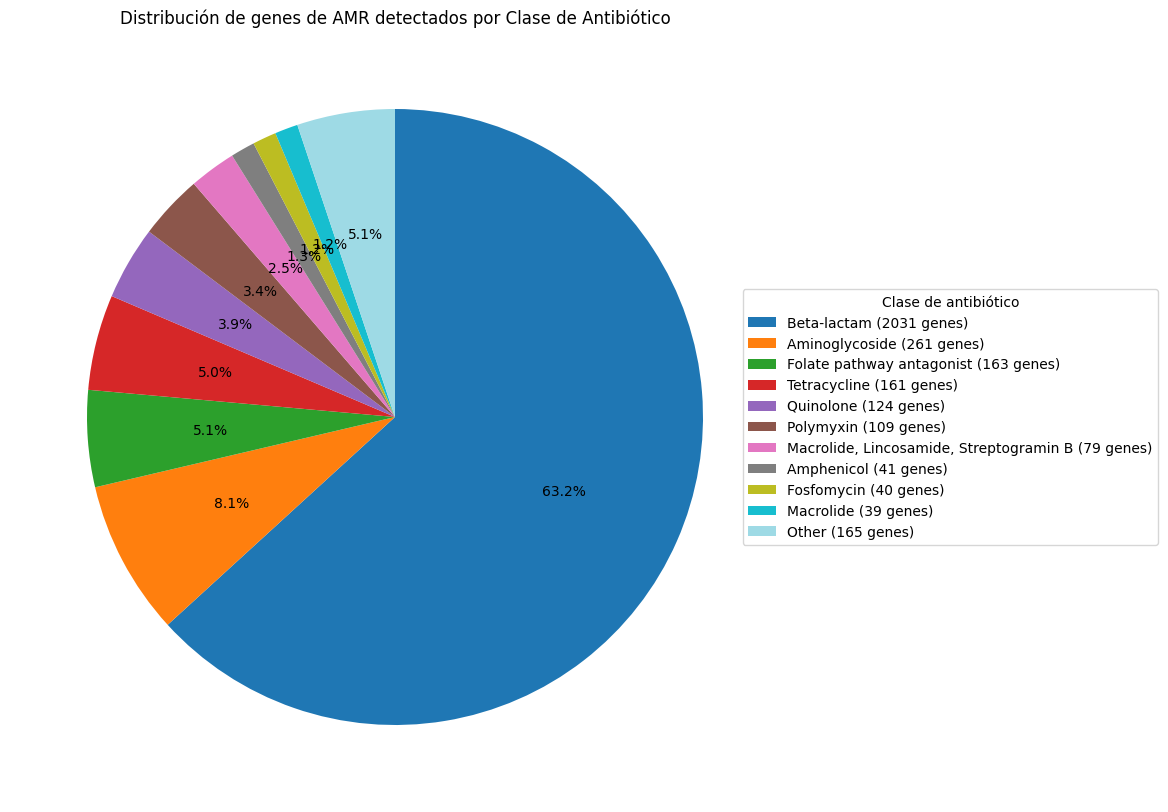

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Input: class_counts with columns ["Antibiotic_Class", "Count"] ---
df = class_counts.copy()

# Total gene count
total = df["Count"].sum()

# Relative abundance
df["Rel"] = df["Count"] / total

# Threshold
threshold = 0.01   # 1%

# Classes above threshold
df_main = df[df["Rel"] >= threshold]

# Classes below threshold → grouped into "Other"
df_other = df[df["Rel"] < threshold]

# Build the final table for plotting
if not df_other.empty:
    other_row = pd.DataFrame({
        "Antibiotic_Class": ["Other"],
        "Count": [df_other["Count"].sum()],
        "Rel": [df_other["Rel"].sum()]
    })
    df_plot = pd.concat([df_main, other_row], ignore_index=True)
else:
    df_plot = df_main.copy()

# Labels & sizes for the pie chart
labels = df_plot["Antibiotic_Class"]
sizes  = df_plot["Count"]

# Distinct colors
colors = plt.cm.tab20(np.linspace(0, 1, len(labels)))

# --- Plot ---
plt.figure(figsize=(12, 10))

patches, texts, autotexts = plt.pie(
    sizes,
    labels=None,                # Legend handles labels instead
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)

plt.title("Distribución de genes de AMR detectados por Clase de Antibiótico")

# Full legend showing ALL classes, including the ones grouped into "Other"
legend_labels = [
    f"{row['Antibiotic_Class']} ({row['Count']} genes)"
    for _, row in df_plot.iterrows()
]

plt.legend(
    patches,
    legend_labels,
    title="Clase de antibiótico",
    bbox_to_anchor=(1.5, 0.5),
    loc="right",
    ncol=1
)
plt.savefig("AMR_ResFinder_CLASS_piechart_genecount.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# Seleccionamos solo columnas con conteos (todas menos Gene y Class)
sample_cols = merged_with_class.columns.difference(["Gene", "Class"])

# Sumamos por clase
class_abundance = merged_with_class.groupby("Class")[sample_cols].sum()

class_abundance


,BOX_13_DIC,BOX_13_JUL,BOX_13_MM,BOX_14_MM,BOX_15_DIC,BOX_15_MM,BOX_16_DIC,BOX_16_JUL,BOX_16_MM,BOX_17_DIC,...,BOX_39_MM,BOX_40_DIC,BOX_40_MM,BOX_41_DIC,BOX_41_JUL,BOX_41_MM,BOX_42_JUL,BOX_44_DIC,BOX_45_MM,Geneid
Class,,,,,,,,,,,,,,,,,,,,,
Aminoglycoside,5633,1914,6875,13800,9783,31870,24213,6210,8817,9370,...,2315,69975,18423,92641,17,6069,1402,13243,8892,Gar_1_NG_070891aac(2')-IIa_1_AB669090aac(2')-I...
"Aminoglycoside, Quinolone",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,aac(6')-Ib-cr_1_DQ303918aac(6')-Ib-cr_2_EF6364...
Amphenicol,2092,351,1683,5965,1242,11003,885,1473,2525,577,...,207,19856,1836,12023,3,936,293,5571,2081,Cfr(D)_1_NG_067192Cfr(E)_1_NG_070225EstDL136_1...
"Amphenicol, Oxazolidinone, Tetracycline",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,poxtA-Ef_1_WP094899500.1poxtA_1_MF095097
"Amphenicol, Quinolone, Folate pathway antagonist",0,0,116,3141,0,106,1,0,1,0,...,1,213,59,0,0,2,3,1,1,OqxA_1_EU370913OqxB_1_EU370913
Beta-lactam,16166,5268,23277,80971,19898,13306,24353,18854,16975,85936,...,14322,139029,56719,61120,284,83174,4416,21109,54446,POM-1_1_GU002295ampH_1_AJ276031ampH_2_HQ586946...
Folate pathway antagonist,6,155,945,765,1640,361,286,698,3,92,...,1,5767,514,473,0,192,3,1757,7,dfrA10_1_L06418dfrA12_10_FM877486dfrA12_1_FJ76...
Fosfomycin,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,fomA_1_AB016934fomB_1_AB016934fosA2_1_EU487198...
Glycopeptide,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,VanEXY_1_FJ872411VanE_1_AF136925VanG2XY_1_FJ87...


<Figure size 1200x600 with 0 Axes>

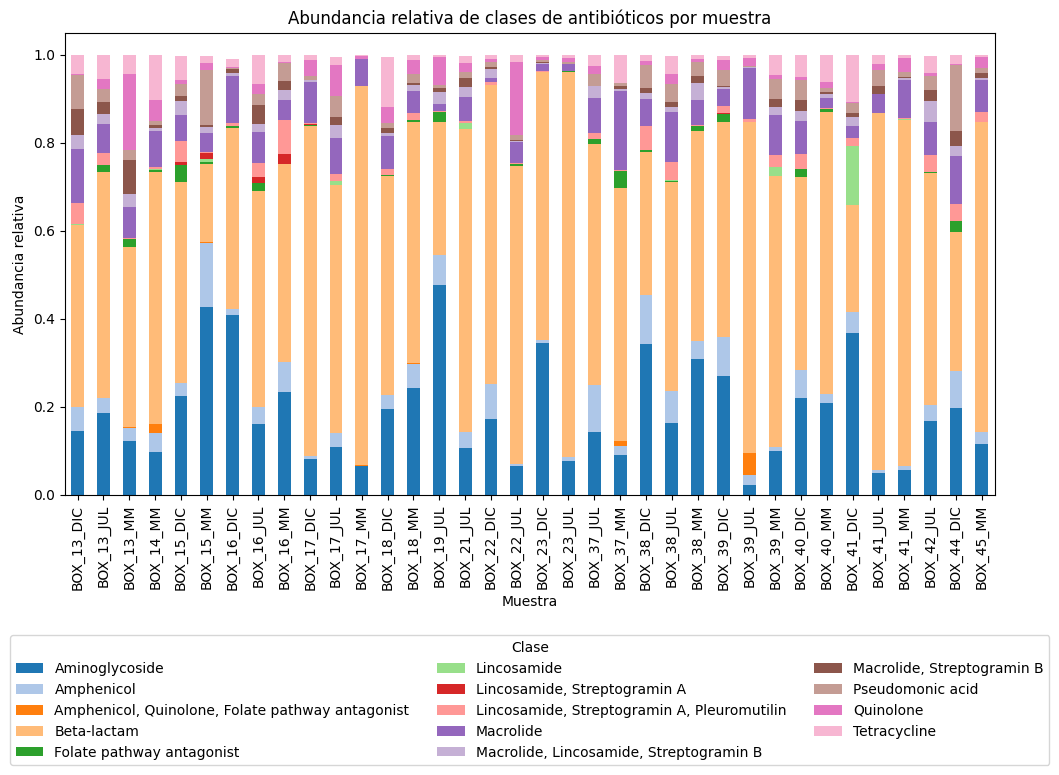

In [9]:
# Intentar convertir todo a número. Los que no puedan → NaN
if "Geneid" in class_abundance.columns:
    class_abundance = class_abundance.drop(columns="Geneid")

# Convert all remaining values to numeric
class_abundance = class_abundance.apply(pd.to_numeric, errors="coerce")

# Calculate relative abundance
relative_abundance = class_abundance.div(class_abundance.sum(axis=0), axis=1)

# Filter those that doesn't have a prevalence of at least 2 samples and a relative abundance of at least 1% (0.01).
prevalence = (relative_abundance > 0).sum(axis=1)
max_rel_abundance = relative_abundance.max(axis=1)
filtered_classes = relative_abundance[
    (prevalence >= 18) &
    (max_rel_abundance >= 0.01)
]

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

palette = plt.cm.tab20.colors  # 20 distinct colors

ax = filtered_classes.T.plot(kind="bar", stacked=True, figsize=(12, 6), color=palette)

plt.ylabel("Abundancia relativa")
plt.xlabel("Muestra")
plt.title("Abundancia relativa de clases de antibióticos por muestra")
ax.legend(
    title="Clase",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.6),   # moves legend down further
    ncol=3
)
plt.savefig("AMR_ResFinder_CLASS_RELAB_p50_ab0.01.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# We generate a table with the counts of the following Genes: blaNDM-5, blaCTX-M-15, blaOXA-1, blaOXA-23, blaTEM-1, blaVIM-1, aac(6')-Ib-cr, qnrB1, qnrE1.
genes_of_interest = [
    "blaNDM", "blaCTX", "blaOXA", "blaOXA",
    "blaTEM","blaTEM", "blaVIM", "aac(6')", "qnrB", "qnrS"
]
# The gene id must at least contain the gene name, so we filter the merged table accordingly.
filtered_genes = merged[merged['Geneid'].str.contains('|'.join(genes_of_interest))]
filtered_genes.to_csv("AMR_ResFinder_genes_of_interest_counts.tsv", sep="\t", index=False)
filtered_genes

# Calculate prevalence % for each gene.
sample_cols = [c for c in filtered_genes.columns if c != "Geneid"]

# Convertir a numérico para evitar errores
filtered_genes[sample_cols] = filtered_genes[sample_cols].apply(pd.to_numeric, errors="coerce")

# Calcular prevalencia: cuántas muestras tienen valor > 0
filtered_genes["Prevalence_count"] = (filtered_genes[sample_cols] > 40).sum(axis=1)

# Total de muestras
n_samples = len(sample_cols)

# Prevalencia en porcentaje
filtered_genes["Prevalence_pct"] = (filtered_genes["Prevalence_count"] / n_samples) * 100

# ===== 2. Promedio de abundancia absoluta =====
filtered_genes["Mean_Abundance"] = filtered_genes[sample_cols].mean(axis=1)

# ===== 3. Agregar columna de grupo =====
def classify_gene(g):
    if g.startswith("blaNDM"):
        return "blaNDM"
    if g.startswith("blaCTX"):
        return "blaCTX"
    if g.startswith("blaOXA"):
        return "blaOXA"
    if g.startswith("blaTEM"):
        return "blaTEM"
    if g.startswith("blaVIM"):
        return "blaVIM"
    if "aac(6')" in g:
        return "aac(6')"
    if g.startswith("qnrB"):
        return "qnrB"
    if g.startswith("qnrS"):
        return "qnrS"
    return "Other"

filtered_genes["Group"] = filtered_genes["Geneid"].apply(classify_gene)

# ===== 4. Rankear por prevalencia y luego abundancia =====
filtered_genes = filtered_genes.sort_values(
    by=["Group", "Prevalence_pct", "Mean_Abundance"],
    ascending=[True, False, False]
)

# ===== 5. Obtener TOP 10 por grupo =====
top10_per_group = (
    filtered_genes.groupby("Group")
                  .head(10)
                  .reset_index(drop=True)
)

top10_per_group

/tmp/ipykernel_3713261/2356623959.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_genes = merged[merged['Geneid'].str.contains('|'.join(genes_of_interest))]
/tmp/ipykernel_3713261/2356623959.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_genes[sample_cols] = filtered_genes[sample_cols].apply(pd.to_numeric, errors="coerce")
/tmp/ipykernel_3713261/2356623959.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view

,Geneid,BOX_15_MM,BOX_37_MM,BOX_37_JUL,BOX_40_MM,BOX_38_DIC,BOX_38_JUL,BOX_42_JUL,BOX_15_DIC,BOX_39_DIC,...,BOX_16_DIC,BOX_18_MM,BOX_38_MM,BOX_41_DIC,BOX_14_MM,BOX_39_MM,Prevalence_count,Prevalence_pct,Mean_Abundance,Group
0,blaCTX-M-8_1_AF189721,1,0,50,0,0,1,2,0,0,...,3,0,150,246,1,50,12,33.333333,225.194444,blaCTX
1,blaCTX-M-14b_1_DQ359215,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,4,11.111111,12.805556,blaCTX
2,blaCTX-M-16_1_AY029068,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,4,11.111111,12.583333,blaCTX
3,blaCTX-M-9_1_AF174129,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,4,11.111111,12.444444,blaCTX
4,blaCTX-M-51_1_DQ211987,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,5.555556,8.472222,blaCTX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,qnrS3_1_EU077611,31,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.000000,1.222222,qnrS
66,qnrS7_1_KF730651,23,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.000000,1.111111,qnrS
67,qnrS8_1_KF730652,23,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.000000,1.027778,qnrS
68,qnrS1_1_AB187515,22,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.000000,1.000000,qnrS


In [11]:
# Now we grab the original merged table and collapse it by gene family
# First, we need to collapse all the gene_ids that belong to the same gene family,
# To do that, we should keep only the part of the gene_id before the first underscore or hyphen
# Also, it should count as the same gene family those that differ only by a trailing number or parenthesis.

import sys
import pandas as pd
import re

def normalize_gene_id(gene_id):
    # Remove anything after a "("
    gene_id = gene_id.split('(')[0]
    # Keep only part before underscore or hyphen
    base = re.split(r'[_-]', gene_id)[0]
    # Remove anything that comes after a number (that number included)
    base = re.sub(r'\d.*', '', base)
    return base

# Check that the first column is gene_id
first_col = merged.columns[0]
merged[first_col] = merged[first_col].astype(str)

# Normalize gene_ids to family ids
merged['gene_family'] = merged[first_col].apply(normalize_gene_id)

# Collapse by gene_family (sum counts)
collapsed = merged.groupby('gene_family', as_index=False).sum(numeric_only=True)

collapsed 

,gene_family,BOX_15_MM,BOX_37_MM,BOX_37_JUL,BOX_40_MM,BOX_38_DIC,BOX_38_JUL,BOX_42_JUL,BOX_15_DIC,BOX_39_DIC,...,BOX_18_DIC,BOX_17_JUL,BOX_17_MM,BOX_39_JUL,BOX_16_DIC,BOX_18_MM,BOX_38_MM,BOX_41_DIC,BOX_14_MM,BOX_39_MM
0,ARR,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Cfr,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CmlA,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,EstDL,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,FloR,0,0,0,0,0,0,0,0,0,...,0,0,166,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256,tmexD,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
257,tva,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
258,vat,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
259,vga,221,272,161,289,6713,73,332,2059,3167,...,2214,205,54,387,396,1102,65,2001,721,636


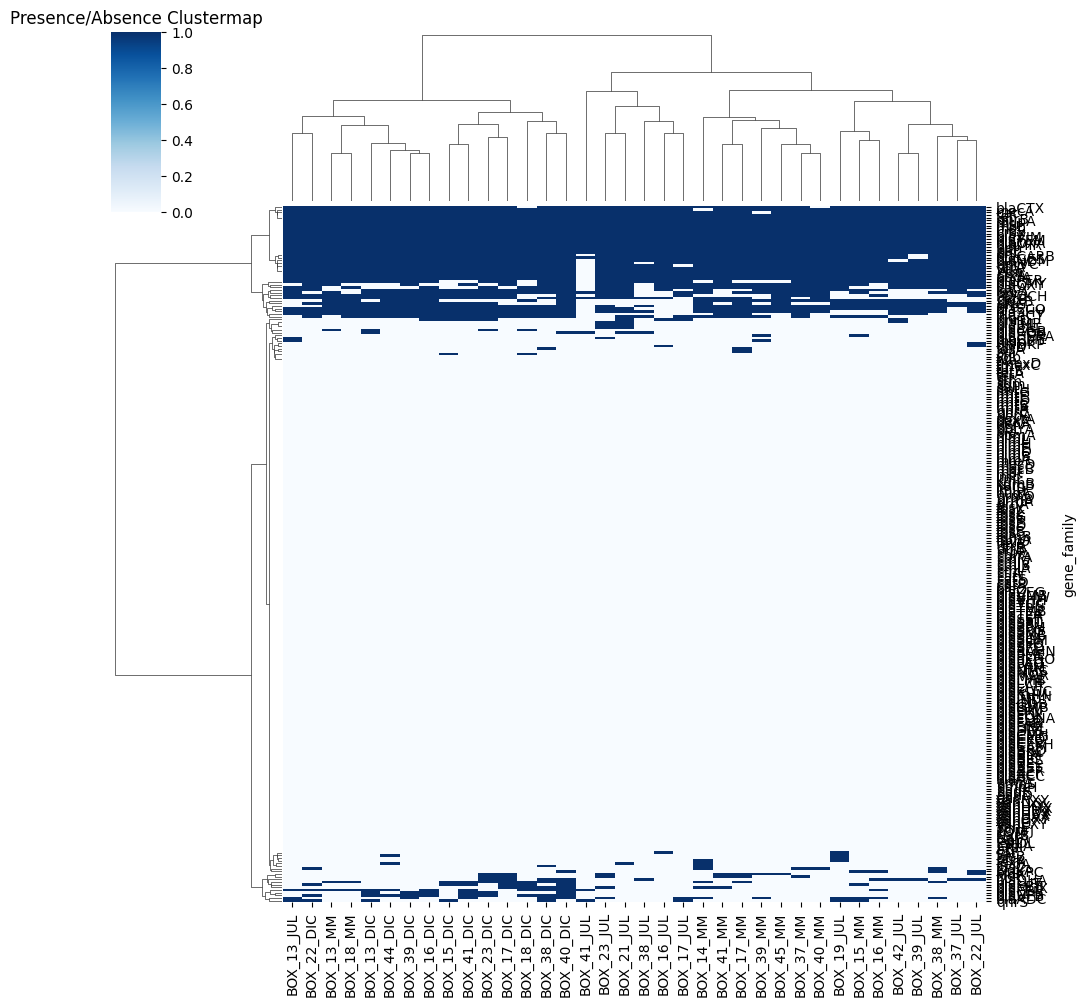

In [12]:
# Now with the collapsed table, we create a presence/absence clustermap again
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

# Convert counts to presence/absence (1 = present, 0 = absent)
presence_absence = collapsed.set_index("gene_family").astype(bool).astype(int)

# Create a clustermap
sns.clustermap(presence_absence, cmap="Blues", method="ward", figsize=(10, 10), yticklabels=True)
plt.title("Presence/Absence Clustermap")
plt.savefig("AMR_ResFinder_collapsed_presence_absence_clustermap.png", dpi=300)
plt.show()

Mean of medians: 146.639846743295, Threshold for filtering: 43.9919540229885


/tmp/ipykernel_3713261/1707436343.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  thresholded[numeric_cols] = thresholded[numeric_cols].applymap(


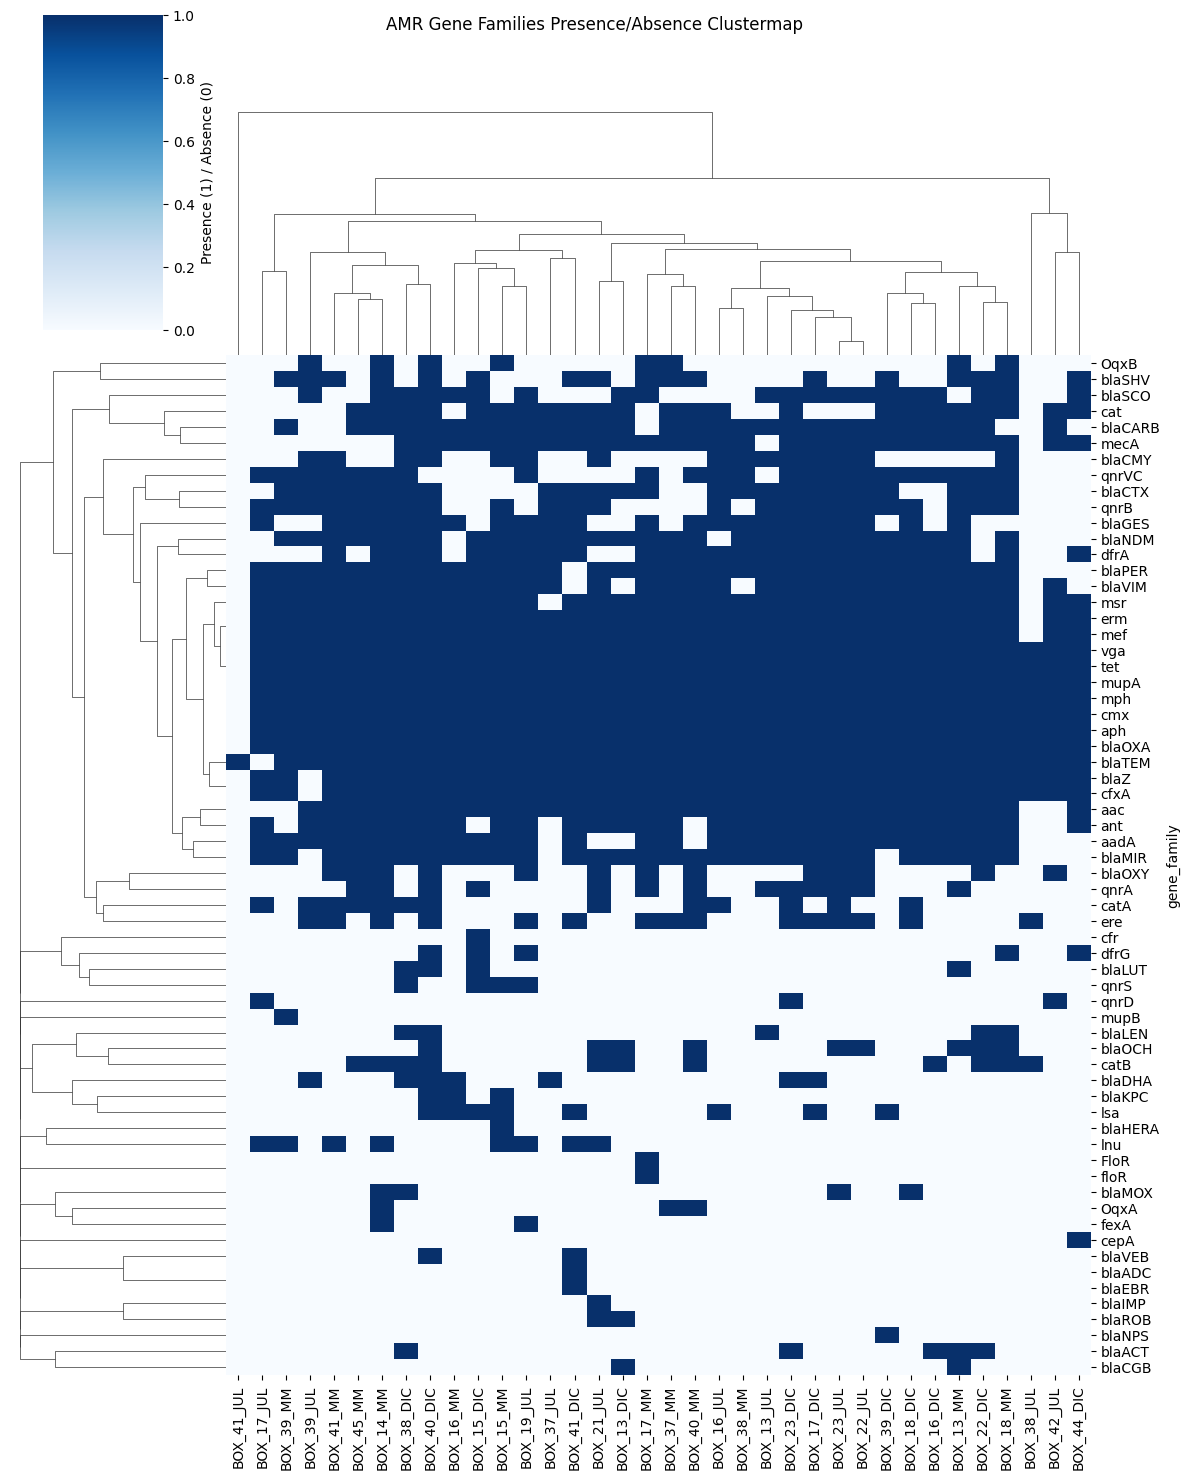

In [13]:
# Now a simplified version of the plot without the gene families that had no presence in any sample
def compute_filter_stats(collapsed_df, numeric_cols, multiplier):
    # compute median across numeric columns for each family (row-wise)
    collapsed_df['median'] = collapsed_df[numeric_cols].median(axis=1)
    mean_of_medians = collapsed_df['median'].mean()
    threshold = mean_of_medians * multiplier
    return mean_of_medians, threshold

mean_of_medians, threshold = compute_filter_stats(collapsed, collapsed.columns[1:-1], 0.30)
print(f"Mean of medians: {mean_of_medians}, Threshold for filtering: {threshold}")

# We pass a filter of abundance > 10% of the mean of the medians, rounded to the nearest integer. 
# But the filter must be for each species count not for the median.
# 1. Filtrar familias donde al menos un valor supera el umbral
filtered = collapsed[collapsed[collapsed.columns[1:-1]].max(axis=1) > threshold]

# 2. Reemplazar por 0 los valores que no superan el umbral
thresholded = filtered.copy()
numeric_cols = filtered.columns[1:-1]  # todas las especies

thresholded[numeric_cols] = thresholded[numeric_cols].applymap(
    lambda x: 1 if x > threshold else 0
)

# 3. Convertir a matriz presencia/ausencia limpia
presence_absence = thresholded.set_index("gene_family")
presence_absence = presence_absence.drop(columns=['median'], errors='ignore')

# Create clustermap
g = sns.clustermap(
    presence_absence,
    cmap="Blues",
    cbar_kws={'label': 'Presence (1) / Absence (0)'},
    figsize=(12, 14),
    yticklabels=True,
    metric="jaccard",
    method="complete",
    cbar_pos=(0.04, 0.825, 0.1, 0.225)
)
# Add a title properly
g.fig.suptitle("AMR Gene Families Presence/Absence Clustermap", y=1.05)
# Save the figure
g.savefig("AMR_ResFinder_gene_families_presence_absence_clustermap_jaccard_complete.png", dpi=300)
plt.show()


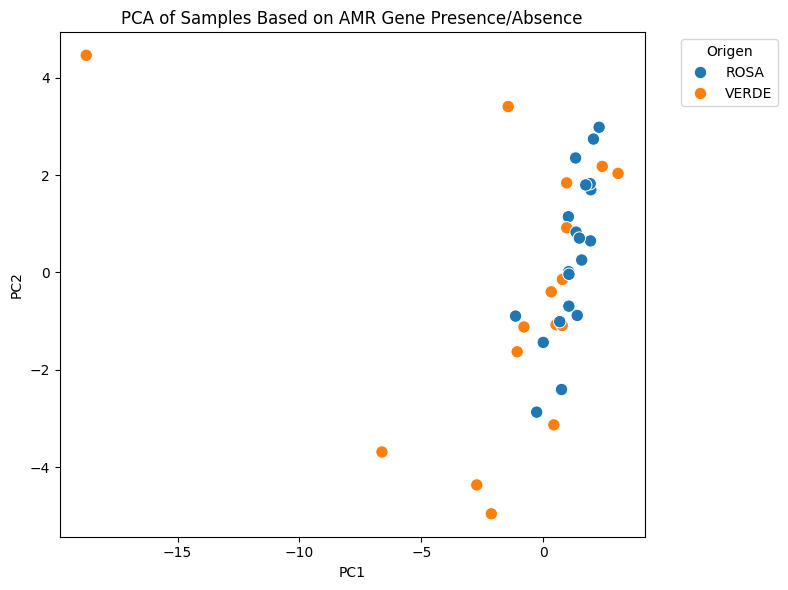

In [14]:
# lets make a PCA of presence abscence data
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(presence_absence)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'], index=presence_absence.index)
pca_df

# 1. Asegurar que metadata y matrix tienen el mismo índice
samples = presence_absence.columns
metadata_subset = metadata.copy()
metadata_subset = metadata_subset[metadata_subset['POOL'].astype(str).isin(samples)]
metadata_subset = metadata_subset.set_index('POOL').loc[samples]

# 2. Transponer matriz: filas = samples
pa_for_pca = presence_absence.T

# 3. Escalado
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pa_for_pca)

# 4. PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# 5. Crear dataframe del PCA
pca_df = pd.DataFrame({
    "PC1": pca_result[:,0],
    "PC2": pca_result[:,1],
    "ORIGEN": metadata_subset["ORIGEN"].values
}, index=samples)

# 6. Plot coloreado
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="ORIGEN",
    palette="tab10",
    s=80
)
plt.title("PCA of Samples Based on AMR Gene Presence/Absence")
plt.legend(title="Origen", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("AMR_ResFinder_PCA_by_ORIGEN.png", dpi=300)
plt.show()

In [15]:
metadata

,POOL,PANEL,BARCODE,ORIGEN,POOL_NORMALIZACION,BARCODE_norm
0,BOX_13_JUL,AMR,281,ROSA,TANDA_1,281
1,BOX_17_JUL,AMR,282,ROSA,TANDA_1,282
2,BOX_19_JUL,AMR,283,ROSA,TANDA_1,283
3,BOX_16_JUL,AMR,284,ROSA,TANDA_1,284
4,BOX_21_JUL,AMR,285,ROSA,TANDA_1,285
5,BOX_22_JUL,AMR,286,ROSA,TANDA_1,286
6,BOX_23_JUL,AMR,287,ROSA,TANDA_1,287
7,BOX_37_JUL,AMR,288,VERDE,TANDA_1,288
8,BOX_38_JUL,AMR,290,VERDE,TANDA_1,290
9,BOX_39_JUL,AMR,289,VERDE,TANDA_1,289
